We’ll compare the conclusions from the overall EDA with those from the EDA focused on the DACH region.

In [36]:
# Import necessary libraries
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [37]:
# Setting the path to the dataset
PATH = "../survey_results_public.csv"

In [38]:
# Loading the dataset into a DataFrame
df = pd.read_csv(PATH)

C:\Users\tetya\AppData\Local\Temp\ipykernel_28252\3191969852.py:2: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH)


In [39]:
# Displaying the first few rows of the DataFrame
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [40]:
# Filtering the DataFrame to include only respondents who are developers by profession and are either employed or independent contractors, freelancers, or self-employed
df_eda = df[(df["MainBranch"] == "I am a developer by profession") & (df["Employment"].isin(["Employed", "Independent contractor, freelancer, or self-employed"]))]

In [41]:
# Displaying the shape of the filtered DataFrame
df_eda.shape

(34146, 172)

In general there are 34146 responses among employed or independent developers.

In [42]:
# Displaying the shape of the filtered DataFrame for respondents from Germany, Austria, and Switzerland
df_dach_eda = df_eda[df_eda["Country"].isin(["Germany", "Austria", "Switzerland"])]
df_dach_eda.shape

(2830, 172)

There are 2830 responses from DACH region.

#### **1. Number of responses**

In [43]:
# Checking missing values among respondents from all over the world
df_eda.isna().sum()

ResponseId                 0
MainBranch                 0
Age                        0
EdLevel                   66
Employment                 0
                       ...  
AIAgentExtWrite        33484
AIHuman                12893
AIOpen                 17559
ConvertedCompYearly    14674
JobSat                  9197
Length: 172, dtype: int64

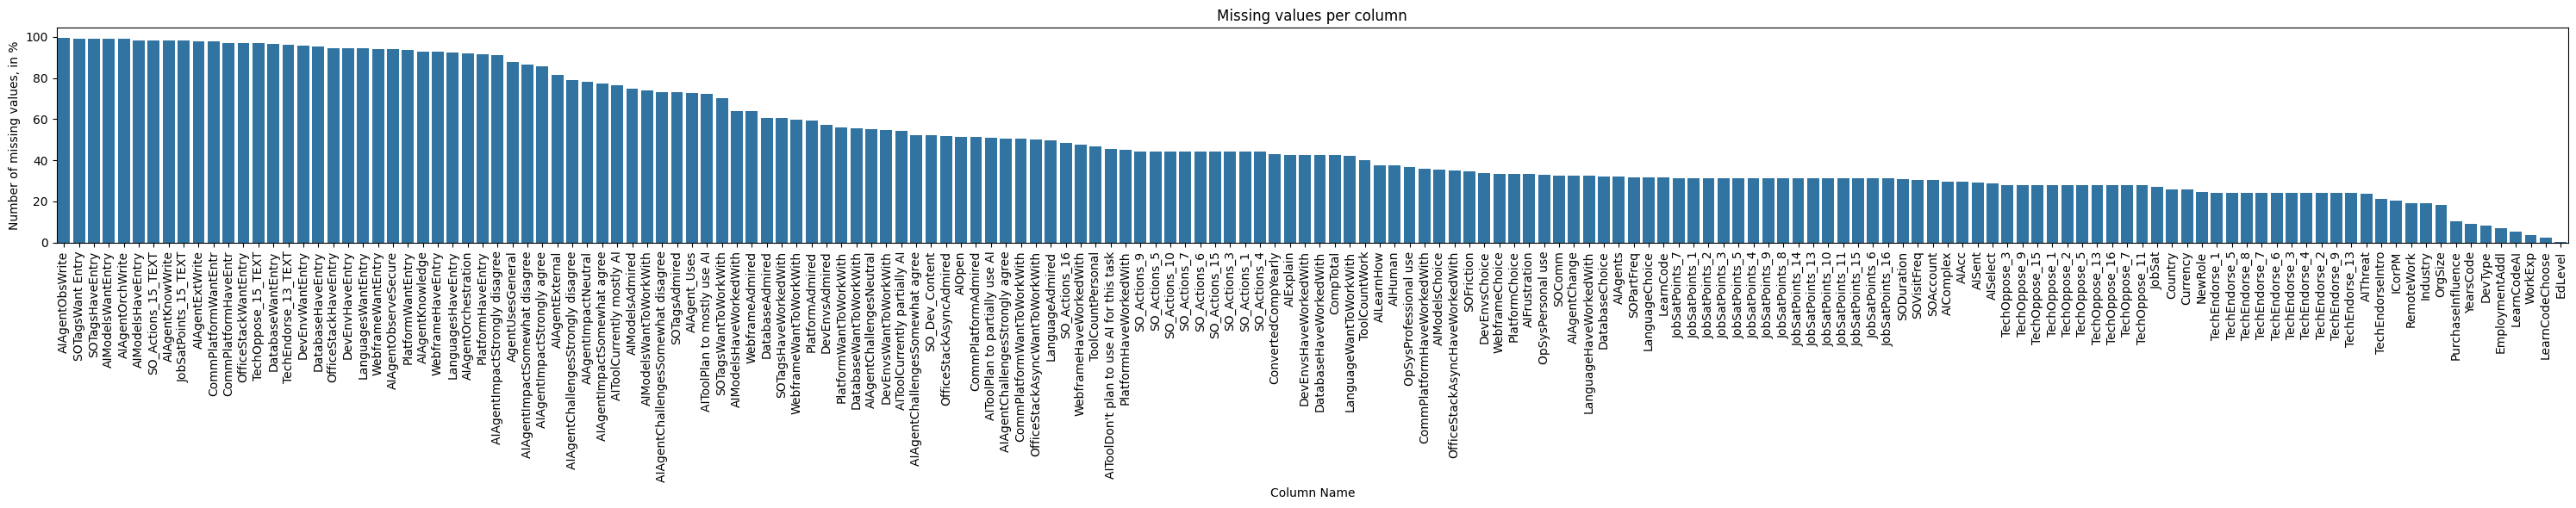

In [44]:
# Visualizing the number of missing values per column
missing = df_eda.isna().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(30, 6))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xticks(rotation=90)
plt.xlabel("Column Name")
plt.ylabel("Number of missing values, in %")
plt.title("Missing values per column")

plt.tight_layout()
plt.show()

Overall, there are many columns with around 95% missing data. Especially ignored were questions about AI, Stackoverflow, commmunity platforms, different databases and environments. In general, most columns have more or less 50% missing values.

In [45]:
# Checking missing values among respondents from Germany, Austria, and Switzerland
df_dach_eda.isna().sum()

ResponseId                0
MainBranch                0
Age                       0
EdLevel                   7
Employment                0
                       ... 
AIAgentExtWrite        2746
AIHuman                 363
AIOpen                  878
ConvertedCompYearly     604
JobSat                  116
Length: 172, dtype: int64

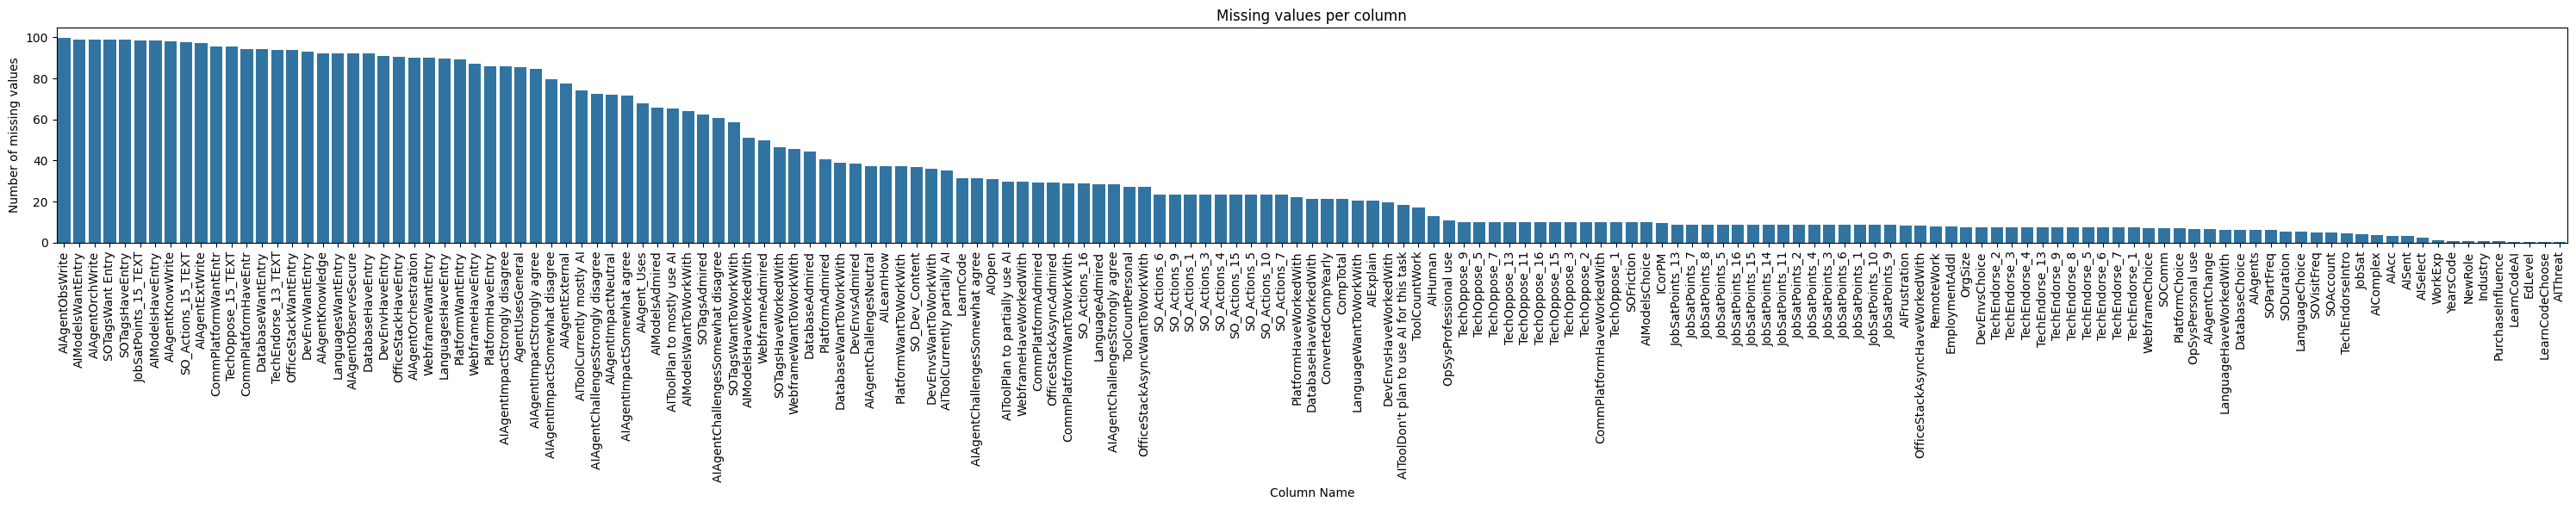

In [46]:
# Visualizing the number of missing values per column for respondents from Germany, Austria, and Switzerland
missing_overall = df_dach_eda.isna().mean() * 100
missing_overall = missing_overall[missing_overall > 0].sort_values(ascending=False)

plt.figure(figsize=(30, 6))

sns.barplot(
    x=missing_overall.index,
    y=missing_overall.values
)

plt.xticks(rotation=90)
plt.xlabel("Column Name")
plt.ylabel("Number of missing values")
plt.title("Missing values per column")

plt.tight_layout()
plt.show()

The graph is steeper, which suggests that although respondents from the DACH region also tended to skip questions about AI, Stack Overflow, commmunity platforms, different databases and environments and so on, they were more likely to answer the other questions.

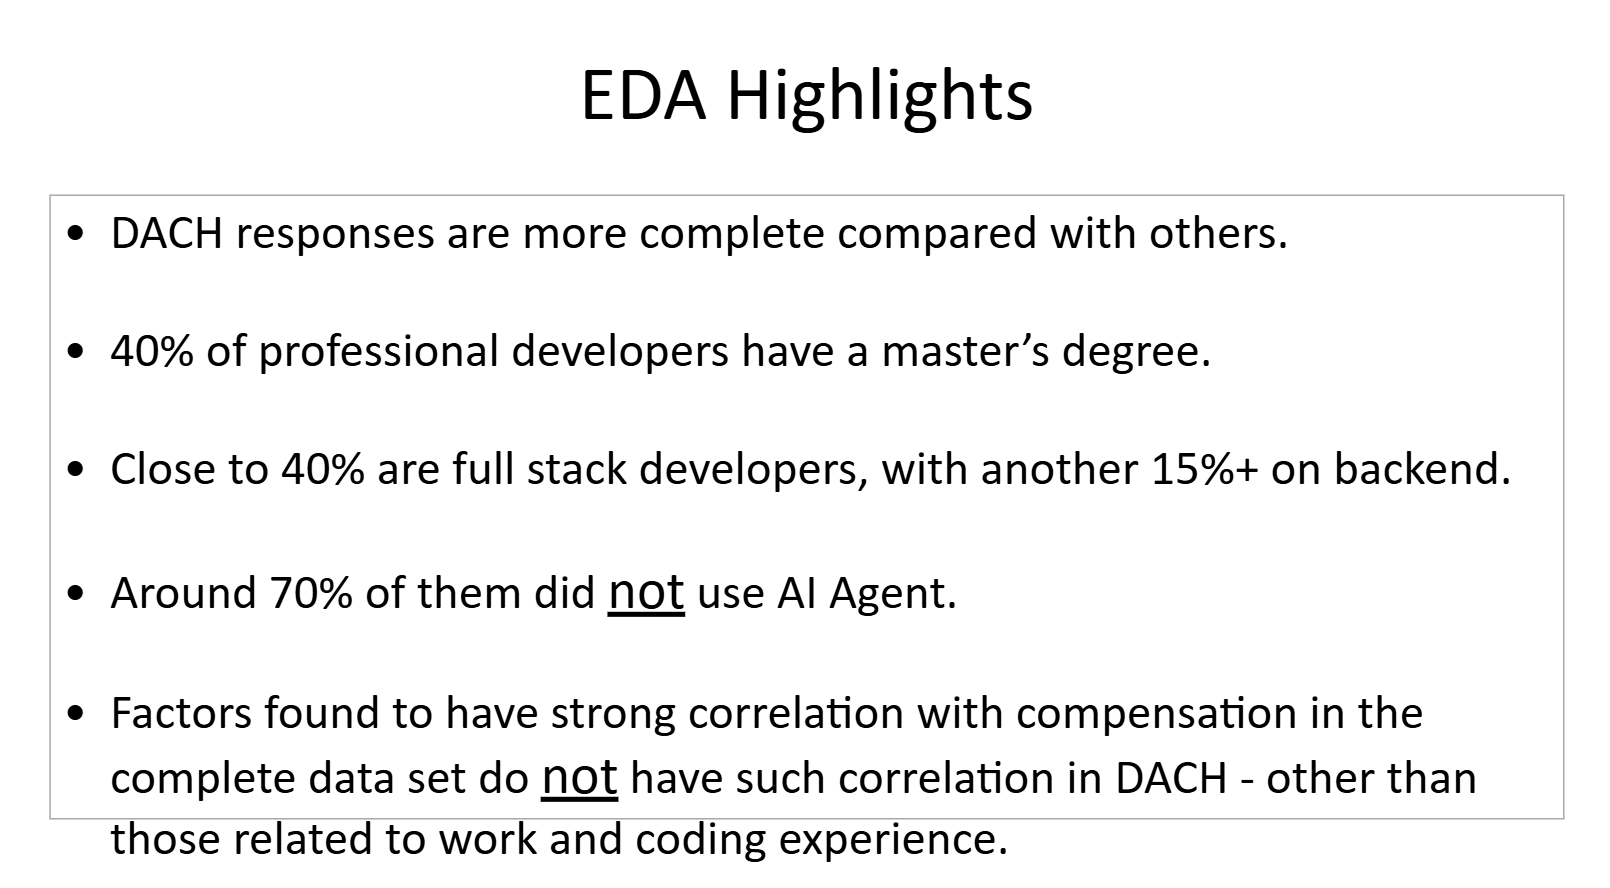

#### **2. Education**

In [47]:
# Displaying the value counts for the "EdLevel" column in the filtered DataFrame for respondents from all over the world
df_eda["EdLevel"].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          15754
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                        9788
Some college/university study without earning a degree                                 3770
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     1571
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         1569
Associate degree (A.A., A.S., etc.)                                                    1071
Other (please specify):                                                                 325
Primary/elementary school                                                               232
Name: count, dtype: int64

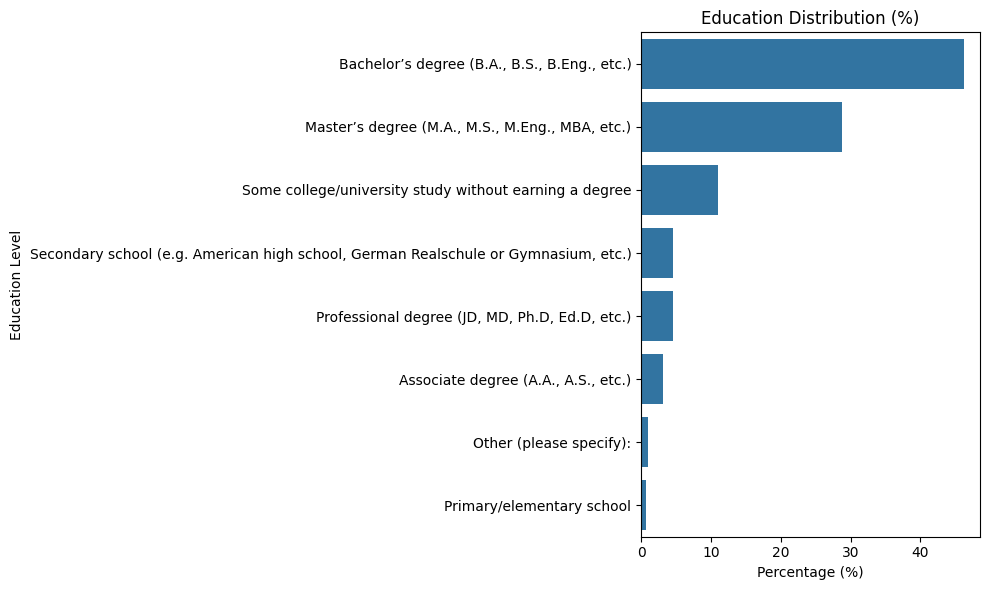

In [49]:
# Visualizing the distribution of education levels among respondents from all over the world
edu_pct = df_eda['EdLevel'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=edu_pct.values,
    y=edu_pct.index
)

plt.xlabel("Percentage (%)")
plt.ylabel("Education Level")
plt.title("Education Distribution (%)")

plt.tight_layout()
plt.show()

In general around 50% responders from all over the world have Bachelor's degree. Around 30% Master's.

In [50]:
# Displaying the value counts for the "EdLevel" column in the filtered DataFrame for respondents from Germany, Austria, and Switzerland
df_dach_eda["EdLevel"].value_counts()

EdLevel
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       1127
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                           781
Some college/university study without earning a degree                                 302
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     272
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         189
Associate degree (A.A., A.S., etc.)                                                     80
Other (please specify):                                                                 59
Primary/elementary school                                                               13
Name: count, dtype: int64

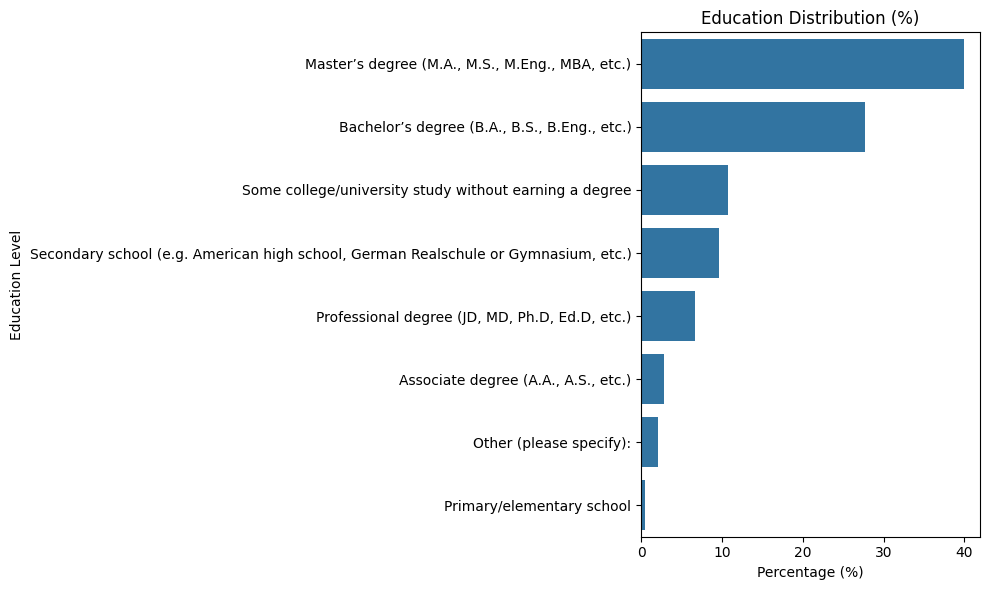

In [51]:
# Visualizing the distribution of education levels among respondents from Germany, Austria, and Switzerland
edu_dach_pct = df_dach_eda['EdLevel'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=edu_dach_pct.values,
    y=edu_dach_pct.index
)

plt.xlabel("Percentage (%)")
plt.ylabel("Education Level")
plt.title("Education Distribution (%)")

plt.tight_layout()
plt.show()

In DACH region situation is the opposite. Around 40% of responders have Master's degree, around 30% Bachelor's. Maybe reason is duration of study in DACH region, which is 3 years for Bachelor's Degree and another 2 for Master's. In other countries it can take 4-5 years only for Bachelor's. As well education in DACH region has higher standarts and is in general very affordable.

#### **3. Developer types**

In [52]:
# Displaying the value counts for the "DevType" column in the filtered DataFrame for respondents from all over the world
df_eda["DevType"].value_counts()

DevType
Developer, full-stack                            11190
Developer, back-end                               5935
Architect, software or solutions                  2195
Developer, desktop or enterprise applications     1691
Developer, front-end                              1657
Developer, mobile                                 1234
Developer, embedded applications or devices       1129
Engineering manager                                724
DevOps engineer or professional                    716
Data engineer                                      613
Other (please specify):                            560
AI/ML engineer                                     531
Data scientist                                     330
Senior executive (C-suite, VP, etc.)               329
Developer, game or graphics                        323
Academic researcher                                316
Cloud infrastructure engineer                      297
Founder, technology or otherwise                   285
De

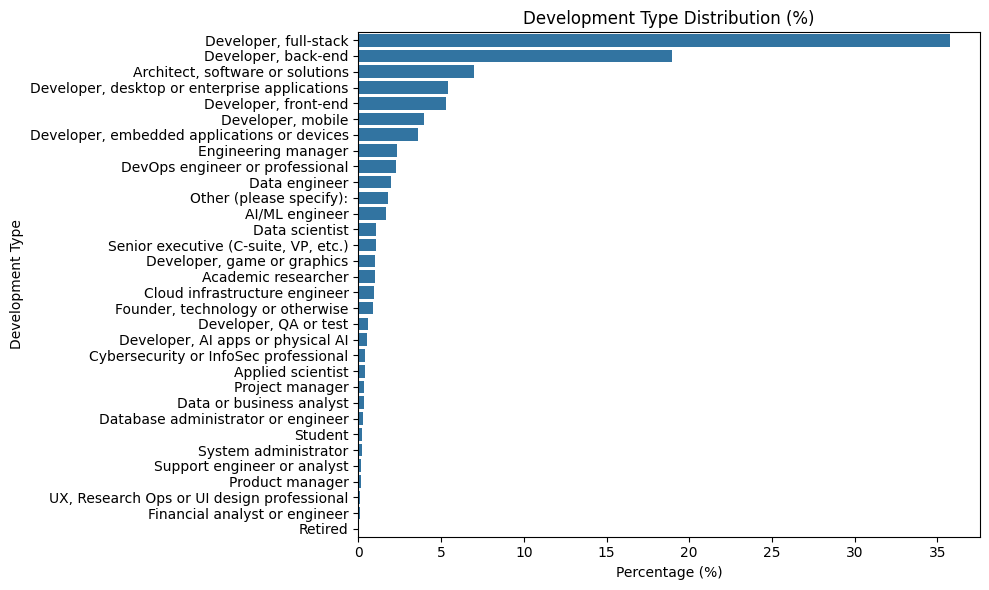

In [53]:
# Visualizing the distribution of development types among respondents from all over the world
dev_pct = df_eda['DevType'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=dev_pct.values,
    y=dev_pct.index
)

plt.xlabel("Percentage (%)")
plt.ylabel("Development Type")
plt.title("Development Type Distribution (%)")

plt.tight_layout()
plt.show()

In [54]:
# Displaying the value counts for the "DevType" column in the filtered DataFrame for respondents from Germany, Austria, and Switzerland
df_dach_eda["DevType"].value_counts()

DevType
Developer, full-stack                            1040
Developer, back-end                               457
Architect, software or solutions                  224
Developer, desktop or enterprise applications     201
Developer, embedded applications or devices       135
Developer, front-end                              126
Developer, mobile                                  99
DevOps engineer or professional                    94
Academic researcher                                64
Other (please specify):                            56
Data scientist                                     41
Engineering manager                                39
Data engineer                                      37
AI/ML engineer                                     33
Cloud infrastructure engineer                      27
Senior executive (C-suite, VP, etc.)               22
Developer, game or graphics                        19
Applied scientist                                  18
Cybersecurity or Inf

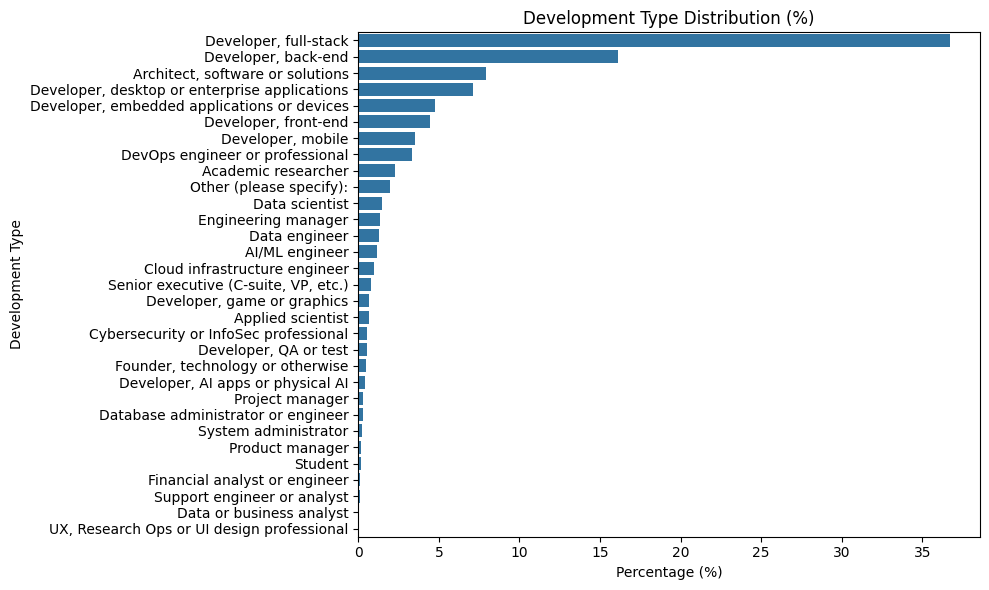

In [55]:
# Visualizing the distribution of development types among respondents from Germany, Austria, and Switzerland
dev_dach_pct = df_dach_eda['DevType'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=dev_dach_pct.values,
    y=dev_dach_pct.index
)

plt.xlabel("Percentage (%)")
plt.ylabel("Development Type")
plt.title("Development Type Distribution (%)")

plt.tight_layout()
plt.show()

In general, there are no major differences in developer types between the global sample and the DACH region. Around 40% are full-stack developers and about 20% are back-end developers. However, embedded systems developers are slightly more common in the DACH region.

#### **4. AI Agents**

In [ ]:
# Displaying the value counts for the "AIAgents" column in the filtered DataFrame for respondents from all over the world
df_eda["AIAgents"].value_counts()

AIAgents
No, and I don't plan to                                  8408
No, but I plan to                                        3996
Yes, I use AI agents at work daily                       3474
No, I use AI exclusively in copilot/autocomplete mode    3332
Yes, I use AI agents at work weekly                      2159
Yes, I use AI agents at work monthly or infrequently     1782
Name: count, dtype: int64

In [57]:
# Creating a new column "AIAgents_clean" that indicates whether the respondent has used AI agents or not
df_eda["AIAgents_clean"] = df_eda["AIAgents"].str.lower().apply(
    lambda x: "Yes" if "yes" in str(x) else "No"
)

In [59]:
# Displaying the value counts for the "AIAgents_clean" column in the filtered DataFrame for respondents from all over the world
df_eda["AIAgents_clean"].value_counts()

AIAgents_clean
No     26731
Yes     7415
Name: count, dtype: int64

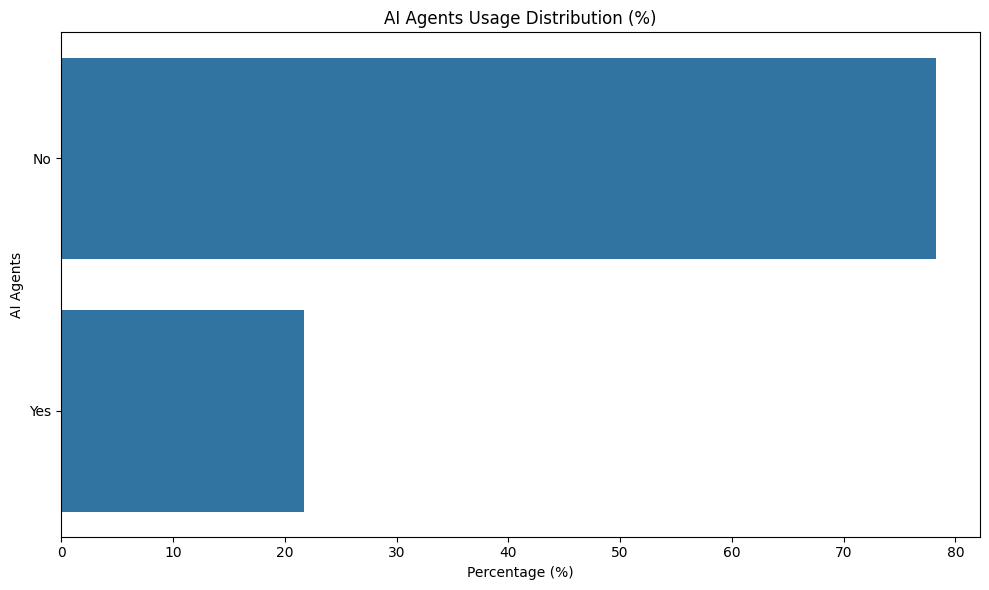

In [61]:
# Visualizing the distribution of AI agents usage among respondents from all over the world
ai_pct = df_eda['AIAgents_clean'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=ai_pct.values,
    y=ai_pct.index
)

plt.xlabel("Percentage (%)")
plt.ylabel("AI Agents")
plt.title("AI Agents Usage Distribution (%)")

plt.tight_layout()
plt.show()

In [62]:
# Displaying the value counts for the "AIAgents" column in the filtered DataFrame for respondents from Germany, Austria, and Switzerland
df_dach_eda["AIAgents"].value_counts()

AIAgents
No, and I don't plan to                                  1136
No, but I plan to                                         434
No, I use AI exclusively in copilot/autocomplete mode     360
Yes, I use AI agents at work daily                        282
Yes, I use AI agents at work weekly                       230
Yes, I use AI agents at work monthly or infrequently      218
Name: count, dtype: int64

In [63]:
# Creating a new column "AIAgents_clean" that indicates whether the respondent has used AI agents or not
df_dach_eda["AIAgents_clean"] = df_dach_eda["AIAgents"].str.lower().apply(
    lambda x: "Yes" if "yes" in str(x) else "No"
)

In [64]:
# Displaying the value counts for the "AIAgents_clean" column in the filtered DataFrame for respondents from Germany, Austria, and Switzerland
df_dach_eda["AIAgents_clean"].value_counts()

AIAgents_clean
No     2100
Yes     730
Name: count, dtype: int64

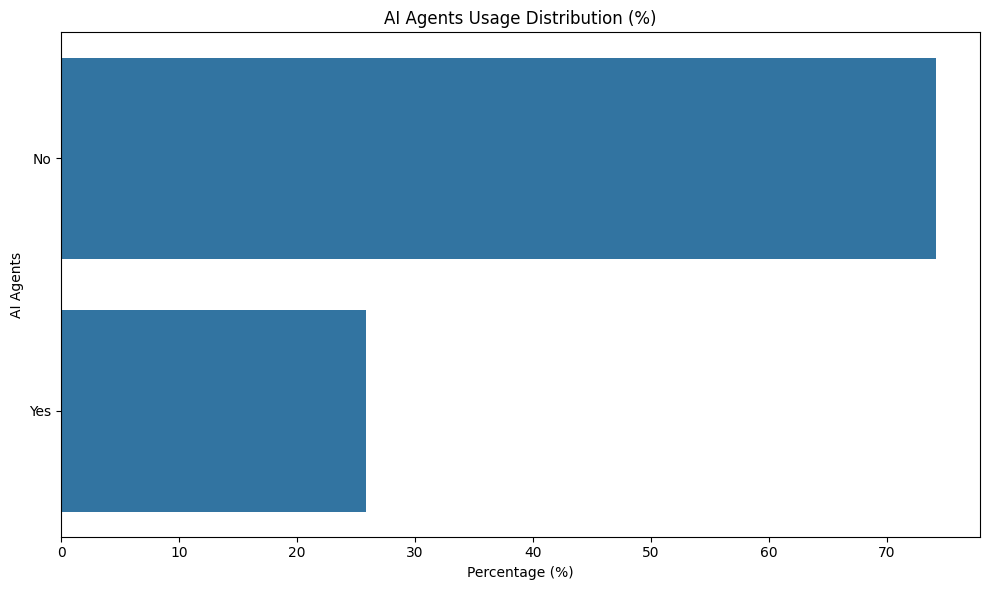

In [65]:
# Visualizing the distribution of AI agents usage among respondents from Germany, Austria, and Switzerland
ai_dach_pct = df_dach_eda['AIAgents_clean'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=ai_dach_pct.values,
    y=ai_dach_pct.index
)

plt.xlabel("Percentage (%)")
plt.ylabel("AI Agents")
plt.title("AI Agents Usage Distribution (%)")

plt.tight_layout()
plt.show()

Among the world 80% of responders have never used AI agents. In DACH region it is only 75%.